In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [15]:
df = pd.read_csv("CHURN.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['tenure', 'MonthlyCharges', 'TotalCharges'])

In [18]:
x = df[['tenure', 'MonthlyCharges']]

In [19]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [25]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['Churn_Cluster'] = kmeans.fit_predict(x_scaled)

<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

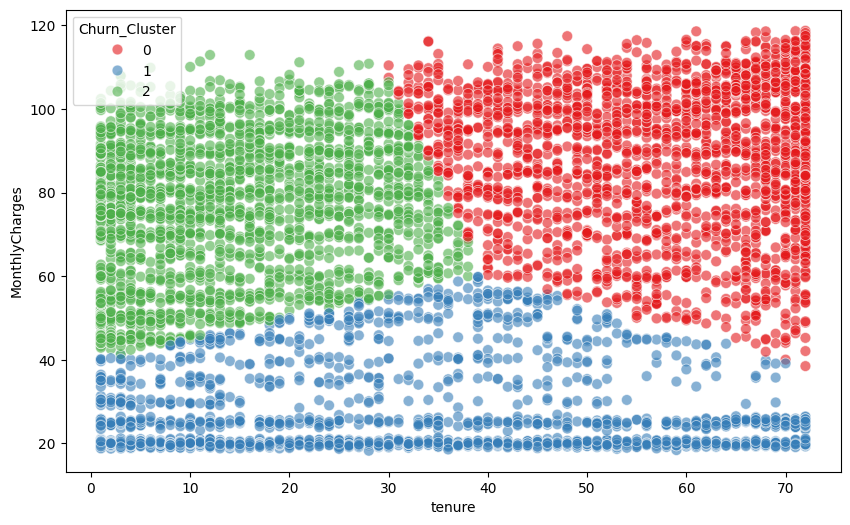

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df['tenure'], 
    y=df['MonthlyCharges'], 
    hue=df['Churn_Cluster'], 
    palette='Set1', 
    s=60, 
    alpha=0.6,
    data=df
)

In [28]:
import pickle

with open(r'churn.pkl', 'wb') as file:
    pickle.dump(kmeans, file)

with open(r'scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)